#  NYC und weitere Städte: Datenbereinigung, erste einfache EDA und lineare Regression

In diesem Notebook werden erste Versuche unternommen, um den Airbnb-Datensatz von New York City zu bereinigen, eine einfache explorative Datenanalyse (EDA) durchzuführen und eine lineare Regression auszuprobieren, um mögliche Zusammenhänge zwischen verschiedenen Merkmalen zu untersuchen. Wichtige Erkenntnisse und Ideen wurden dann weiterentwickelt und ins Notebook *draft analysis* übernommen. Zu einem späteren Zeitpunkt wurden dann weitere Datensätze amerikanischer Städte eingelesen, um zu sehen, ob diese Städte ähnlich verarbeitet werden können und ob sich Muster erkennen lassen.

Erkenntnis: Leider fehlen in den Datensätzen der Städte oftmals die Werte in der Spalte 'price' oder die Spalte 'neighbourhood_group_cleansed' komplett. Damit kann weder die Zielvariable noch die wichtigste kategoriale Variable des OLS-Modells verwendet werden und die lineare Regression zu NYC in *draft analysis* nicht 1:1 auf andere Städte übertragen werden.

Datensatz von https://insideairbnb.com/get-the-data/

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import display

In [22]:
import sys
import os

# Definiert den relativen Pfad zum 'src' Ordner
# .. = Ein Ordner hoch zum Projekt-Root
# /src = Dann in den Ordner src
src_path = os.path.join(os.getcwd(), '..', 'src')

# Fügt diesen Pfad dem Python-Suchpfad hinzu
if src_path not in sys.path:
    sys.path.append(src_path)

print(f"✅ src-Ordner temporär zum Suchpfad hinzugefügt: {src_path}")

✅ src-Ordner temporär zum Suchpfad hinzugefügt: c:\Users\Annette\Data_Science\02_data-analytics\05_regression_projekt_airbnb\notebooks\..\src


In [35]:
df = pd.read_csv("../data/raw/listings_Washington_raw.csv")

In [36]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3344,https://www.airbnb.com/rooms/3344,20250922033906,2025-09-22,city scrape,"White House-Center City, entire 2BR/2BA Condo","This listing is for full, exclusive-to-the-gue...",This is the hottest neighborhood in D.C. at th...,https://a0.muscache.com/pictures/a5261b92-35d9...,4957,...,5.00,5.00,5.00,NaN,f,2,2,0,0,0.05
1,3686,https://www.airbnb.com/rooms/3686,20250922033906,2025-09-23,city scrape,Vita's Hideaway,IMPORTANT NOTES<br />* Carefully read and be s...,We love that our neighborhood is up and coming...,https://a0.muscache.com/pictures/61e02c7e-3d66...,4645,...,4.84,3.91,4.64,NaN,f,1,0,1,0,0.46
2,3943,https://www.airbnb.com/rooms/3943,20250922033906,2025-09-23,city scrape,Historic Rowhouse Near Monuments,You will be staying in high ceiling bedroom w...,This rowhouse is centrally located in the hear...,https://a0.muscache.com/pictures/airflow/Hosti...,5059,...,4.92,4.61,4.77,Hosted License: 5007242201001033,f,5,0,5,0,2.75
3,4197,https://www.airbnb.com/rooms/4197,20250922033906,2025-09-23,city scrape,Capitol Hill Bedroom walk to Metro,This is the middle bedroom upstairs in a resto...,"Our area, the Eastern Market neighborhood of C...",https://a0.muscache.com/pictures/airflow/Hosti...,5061,...,4.98,4.97,4.94,Hosted License: 5007242201000749,f,2,0,2,0,0.34
4,4529,https://www.airbnb.com/rooms/4529,20250922033906,2025-09-22,city scrape,Bertina's House Part One,This is large private bedroom with plenty of...,Very quiet neighborhood and it is easy accessi...,https://a0.muscache.com/pictures/86072003/6709...,5803,...,4.93,4.51,4.83,Exempt,f,2,0,2,0,0.51


In [34]:
df[['price', 'neighbourhood_group_cleansed']].isnull().sum()

price                           1482
neighbourhood_group_cleansed    6374
dtype: int64

In [37]:
df['neighbourhood'].nunique()

1

In [38]:
df.describe()

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,neighbourhood_group_cleansed,latitude,longitude,accommodates,bathrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,6.374000e+03,6.374000e+03,6.374000e+03,6371.000000,6371.000000,0.0,6374.000000,6374.000000,6374.000000,4923.000000,...,5310.000000,5310.000000,5310.000000,5310.000000,5310.000000,6374.000000,6374.000000,6374.000000,6374.000000,5311.000000
mean,6.784002e+17,2.025092e+13,1.899267e+08,301.540418,430.102496,NaN,38.909288,-77.012705,3.822247,1.392139,...,4.792064,4.864678,4.856395,4.744087,4.698780,25.640728,22.375275,2.887355,0.083621,1.980527
std,5.841445e+17,0.000000e+00,2.129364e+08,1077.297539,1403.268298,NaN,0.025403,0.030654,2.495488,0.790438,...,0.329030,0.290529,0.332447,0.372794,0.383402,61.184530,60.550560,11.294602,0.966603,1.924388
min,3.344000e+03,2.025092e+13,4.617000e+03,1.000000,1.000000,NaN,38.820280,-77.112862,1.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,4.047630e+07,2.025092e+13,2.292902e+07,1.000000,2.000000,NaN,38.895522,-77.032160,2.000000,1.000000,...,4.740000,4.860000,4.860000,4.670000,4.630000,1.000000,1.000000,0.000000,0.000000,0.460000
50%,8.392610e+17,2.025092e+13,9.011789e+07,3.000000,5.000000,NaN,38.908813,-77.014310,3.000000,1.000000,...,4.890000,4.945000,4.950000,4.860000,4.790000,3.000000,1.000000,0.000000,0.000000,1.500000
75%,1.226226e+18,2.025092e+13,3.603801e+08,17.000000,24.000000,NaN,38.922760,-76.992410,5.000000,1.500000,...,4.980000,5.000000,5.000000,4.970000,4.900000,11.000000,4.000000,1.000000,0.000000,2.980000
max,1.514511e+18,2.025092e+13,7.193753e+08,5472.000000,9696.000000,NaN,38.994470,-76.910920,16.000000,15.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,257.000000,253.000000,89.000000,14.000000,29.740000


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6374 entries, 0 to 6373
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            6374 non-null   int64  
 1   listing_url                                   6374 non-null   object 
 2   scrape_id                                     6374 non-null   int64  
 3   last_scraped                                  6374 non-null   object 
 4   source                                        6374 non-null   object 
 5   name                                          6374 non-null   object 
 6   description                                   6309 non-null   object 
 7   neighborhood_overview                         3741 non-null   object 
 8   picture_url                                   6374 non-null   object 
 9   host_id                                       6374 non-null   i

## Feature Engineering: Distance to center als neue Spalte

Ausgangspunkt: latitude, longitude   
Ziel: Abstand zum Times Square (als Center von NYC messen)

In [ ]:
# 1. Imports aus der src-Datei
from haversine_distanz import calculate_distance, get_city_center_coords

# 2. DEFINITION DES ZENTRUMS (Dynamischer Abruf)
TARGET_CITY = "New York City, USA" # Beispiel-Stadt
print(f"Suche Koordinaten für: {TARGET_CITY}...")

try:
    center_lat, center_lon = get_city_center_coords(TARGET_CITY)
    print(f"✅ Gefunden: LAT={center_lat}, LON={center_lon}")
except Exception as e:
    print(f"❌ Fehler beim Abruf: {e}")
    # Optional: Fallback auf Default-Werte, falls Abruf fehlschlägt
    # center_lat, center_lon = 40.7580, -73.9855


# 3. ANWENDUNG DER DISTANZBERECHNUNG
if center_lat is not None:
    df['distance_to_center'] = calculate_distance(
        df['latitude'], 
        df['longitude'], 
        center_lat, 
        center_lon
    )

    print("\n✅ Neue Spalte 'distance_to_center' erfolgreich hinzugefügt.")
    print(df[['latitude', 'longitude', 'distance_to_center']].head())

Suche Koordinaten für: New York City, USA...
✅ Gefunden: LAT=40.7127281, LON=-74.0060152

✅ Neue Spalte 'distance_to_center' erfolgreich hinzugefügt.
   latitude  longitude  distance_to_center
0  40.74698  -73.91763            8.364948
1  40.72314  -73.99323            1.581587
2  40.64607  -74.00552            7.412160
3  40.68370  -73.96115            4.972334
4  40.72147  -73.98270            2.192270


In [9]:
from geopy.geocoders import Nominatim
import pandas as pd
import os # Immer noch nützlich für Dateipfad-Handhabung

# Initialisiere den Geocoder (NUR EINMAL ausführen!)
geolocator = Nominatim(user_agent="nyc_airbnb_analysis_project")

def get_city_once(latitude, longitude):
    """
    Führt Reverse Geocoding FÜR EINE EINZIGE KOORDINATE durch, 
    um den relevanten Stadtnamen/Borough zu ermitteln.
    """
    try:
        # Hier MÜSSEN wir KEINEN RateLimiter verwenden, da wir nur eine Abfrage machen.
        location = geolocator.reverse((latitude, longitude), exactly_one=True)
        
        if location and location.raw and 'address' in location.raw:
            address = location.raw['address']
            
            # Da wir in NYC sind, suchen wir nach dem Borough, der oft als 'city' oder 'suburb' erkannt wird
            city = address.get('suburb') or address.get('city') or address.get('borough') or address.get('town')
            
            if city:
                return city.upper()
            
        return "UNKNOWN"
        
    except Exception as e:
        # Falls die Anfrage fehlschlägt
        print(f"FEHLER beim Geocoding der ersten Zeile: {e}")
        return "ERROR_API"

In [10]:
df[['distance_to_center', 'latitude', 'longitude', 'price', 'instant_bookable', 'room_type']].head()

,distance_to_center,latitude,longitude,price,instant_bookable,room_type
0,8.364948,40.74698,-73.91763,$66.00,f,Private room
1,1.581587,40.72314,-73.99323,NaN,t,Private room
2,7.412160,40.64607,-74.00552,NaN,f,Private room
3,4.972334,40.68370,-73.96115,NaN,t,Entire home/apt
4,2.192270,40.72147,-73.98270,$76.00,f,Private room


## Reduktion der Spalten

In [13]:
SPALTEN_REDUZIERT = [
    'accommodates',
    'price',
    'host_total_listings_count',
    'review_scores_rating', 
    'latitude', 
    'longitude', 
    'availability_365',
    'distance_to_center',
    'instant_bookable',
    'room_type'
] 

In [14]:
df_simple = df[SPALTEN_REDUZIERT].copy()

In [15]:
df_simple.head()

,accommodates,price,host_total_listings_count,review_scores_rating,latitude,longitude,availability_365,distance_to_center,instant_bookable,room_type
0,1,$66.00,3.0,4.81,40.74698,-73.91763,77,8.364948,f,Private room
1,2,NaN,1.0,NaN,40.72314,-73.99323,0,1.581587,t,Private room
2,1,NaN,1.0,5.00,40.64607,-74.00552,0,7.412160,f,Private room
3,1,NaN,3.0,5.00,40.68370,-73.96115,0,4.972334,t,Entire home/apt
4,1,$76.00,16.0,4.95,40.72147,-73.98270,168,2.192270,f,Private room


## Löschung aller Zeilen ohne Preis

In [17]:
df_clean = df_simple.dropna(subset=['price']).copy()
print(f"Zeilen nach der Preislöschung: {len(df_clean)}")

Zeilen nach der Preislöschung: 21328


In [18]:
# 1. Entfernen von Währungszeichen ($), Kommas (,) und Leerzeichen
df_clean['price'] = df_clean['price'].astype(str).str.replace(r'[$,\s]', '', regex=True)

# 2. Konvertieren zu numerischem Float
# Wichtig: errors='coerce' verwandelt Einträge, die nicht konvertiert werden können (z.B. leere Zellen, 'N/A'), in NaN.
df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')

In [19]:
df_clean['accommodates'] = df_clean['accommodates'].astype(float)

### Imputation fehlender Werte

In [20]:
IMPUTATIONS_SPALTEN = ['host_total_listings_count', 'review_scores_rating']

for col in IMPUTATIONS_SPALTEN:
    median_wert = df_clean[col].median()
    
    # KORRIGIERT: Keine inplace=True. Das Ergebnis der fillna-Operation 
    # wird direkt der Spalte zugewiesen.
    df_clean[col] = df_clean[col].fillna(median_wert)
    
    print(f"  -> Spalte '{col}': NaNs durch Median ({median_wert:.2f}) ersetzt.")

  -> Spalte 'host_total_listings_count': NaNs durch Median (5.00) ersetzt.
  -> Spalte 'review_scores_rating': NaNs durch Median (4.86) ersetzt.


In [21]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21328 entries, 0 to 36110
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   accommodates               21328 non-null  float64
 1   price                      21328 non-null  float64
 2   host_total_listings_count  21328 non-null  float64
 3   review_scores_rating       21328 non-null  float64
 4   latitude                   21328 non-null  float64
 5   longitude                  21328 non-null  float64
 6   availability_365           21328 non-null  int64  
 7   distance_to_center         21328 non-null  float64
 8   instant_bookable           21328 non-null  object 
 9   room_type                  21328 non-null  object 
dtypes: float64(7), int64(1), object(2)
memory usage: 1.8+ MB


Lückenloser Datensatz liegt vor! 

In [22]:
df_clean.to_csv('listings_short_NYC.csv')

In [23]:
df1=df_clean

## One Hot Encoding: Instant_bookable

In [24]:
from IPython.display import display
display(df1['instant_bookable'].head(20))


0     f
4     f
5     f
7     f
8     f
9     f
10    f
11    f
12    f
14    t
15    f
17    t
20    t
24    t
25    t
27    f
28    f
29    f
32    t
33    f
Name: instant_bookable, dtype: object

In [ ]:
print(df1['instant_bookable'].unique())
mapping = {'t': 1, 'f': 0}
# 1. Umwandlung des String-Features in 0 und 1
df1['is_instant_bookable'] = df1['instant_bookable'].replace(mapping)

# 2. Löschen der alten Spalte
df1 = df1.drop('instant_bookable', axis=1)

# 3. Überprüfung der neuen Spalte
df1['is_instant_bookable'].value_counts()

['f' 't']


C:\Users\Annette\AppData\Local\Temp\ipykernel_28452\2203128008.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['is_instant_bookable'] = df1['instant_bookable'].replace(mapping)


is_instant_bookable
0    15966
1     5362
Name: count, dtype: int64

### One Hot Encoding für 'room_type'

In [26]:
# Untersucht die Spalte 'room_type'
print("--- Überblick über die vorhandenen Room Types ---")
print(df1['room_type'].value_counts())
print("\n--- Als Prozentsatz ---")
print(df1['room_type'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

--- Überblick über die vorhandenen Room Types ---
room_type
Entire home/apt    11985
Private room        8930
Hotel room           234
Shared room          179
Name: count, dtype: int64

--- Als Prozentsatz ---
room_type
Entire home/apt    56.19%
Private room       41.87%
Hotel room           1.1%
Shared room         0.84%
Name: proportion, dtype: object


In [27]:
## SCHRITT 1: ANWENDUNG DES ONE-HOT-ENCODINGS (DUMMIES)

# 1. Anwendung von One-Hot-Encoding auf die Spalte 'room_type'.
# get_dummies entfernt die Originalspalte 'room_type' automatisch und erstellt neue Spalten.
# prefix='room' stellt sicher, dass die neuen Spalten leicht identifizierbar sind.
df = pd.get_dummies(df, columns=['room_type'], prefix='room', dtype=int)


# 2. Überprüfung der neuen Spalten
print("--- Die erzeugten Dummy-Spalten ---")
# Die Ausgabe zeigt nun die vier neuen Spalten in der Spaltenliste:
print(df.filter(regex='^room_').head())

print("\n✅ Die Spalte 'room_type' wurde durch binäre Dummy-Variablen ersetzt.")

# Hinweis: Wenn Sie nun die reduzierte Spaltenliste df_simple erstellen, 
# müssen Sie die vier neuen Spalten hinzufügen und 'room_type' entfernen!

--- Die erzeugten Dummy-Spalten ---
   room_Entire home/apt  room_Hotel room  room_Private room  room_Shared room
0                     0                0                  1                 0
1                     0                0                  1                 0
2                     0                0                  1                 0
3                     1                0                  0                 0
4                     0                0                  1                 0

✅ Die Spalte 'room_type' wurde durch binäre Dummy-Variablen ersetzt.


### EDA

siehe: https://www.youtube.com/watch?v=O2Cw82YR5Bo

In [28]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21328 entries, 0 to 36110
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   accommodates               21328 non-null  float64
 1   price                      21328 non-null  float64
 2   host_total_listings_count  21328 non-null  float64
 3   review_scores_rating       21328 non-null  float64
 4   latitude                   21328 non-null  float64
 5   longitude                  21328 non-null  float64
 6   availability_365           21328 non-null  int64  
 7   distance_to_center         21328 non-null  float64
 8   room_type                  21328 non-null  object 
 9   is_instant_bookable        21328 non-null  int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 1.8+ MB


In [29]:
df1.describe()

,accommodates,price,host_total_listings_count,review_scores_rating,latitude,longitude,availability_365,distance_to_center,is_instant_bookable
count,21328.000000,21328.000000,21328.000000,21328.000000,21328.000000,21328.000000,21328.000000,21328.000000,21328.000000
mean,2.868014,680.526819,244.445940,4.769270,40.727018,-73.944055,251.044120,8.455427,0.251407
std,2.021471,4480.453282,1015.854308,0.381238,0.058734,0.060404,106.941151,5.183807,0.433832
min,1.000000,10.000000,1.000000,1.000000,40.500366,-74.251907,0.000000,0.006350,0.000000
25%,2.000000,89.000000,2.000000,4.760000,40.685195,-73.983262,172.000000,4.877343,0.000000
50%,2.000000,154.000000,5.000000,4.860000,40.726895,-73.953500,276.000000,7.460013,0.000000
75%,4.000000,279.000000,22.000000,4.930000,40.763037,-73.922741,347.000000,11.003034,1.000000
max,16.000000,50104.000000,9764.000000,5.000000,40.912017,-73.711822,365.000000,30.952448,1.000000


#### Zielvariable Price

a) Boxplots

<Axes: xlabel='price'>

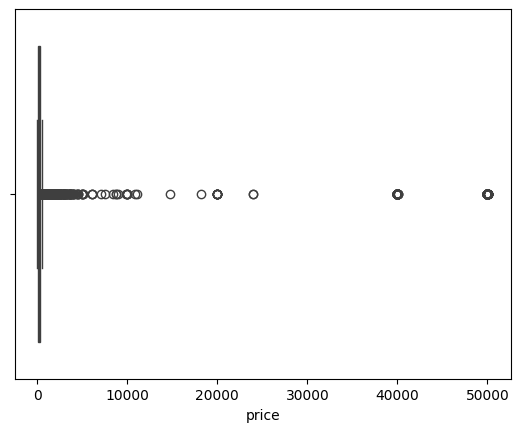

In [30]:
sns.boxplot(x='price', data= df1)

Wenn Sie sich nicht auf einen festen Wert ($1000) festlegen möchten, können Sie auch das 99. Perzentil Ihres eigenen Datensatzes verwenden. Das schließt die extremsten 1% der Ausreißer aus und zeigt 99% der Daten:

99. Perzentil liegt bei: $19514.00


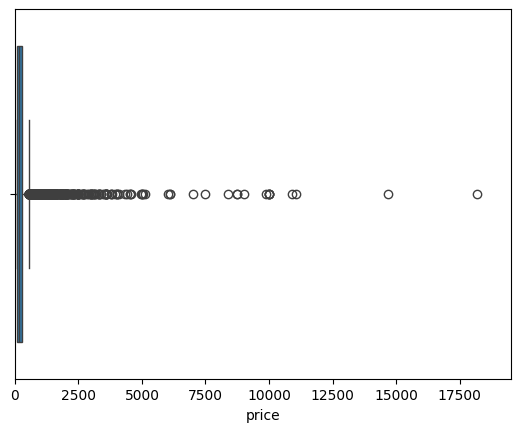

In [31]:
# Berechnung des 99. Perzentils
limit_99 = df1['price'].quantile(0.99)
print(f"99. Perzentil liegt bei: ${limit_99:.2f}") 

# Plot-Befehl mit dem berechneten Limit:
sns.boxplot(x='price', data=df1)
plt.xlim(0, limit_99) 
plt.show()

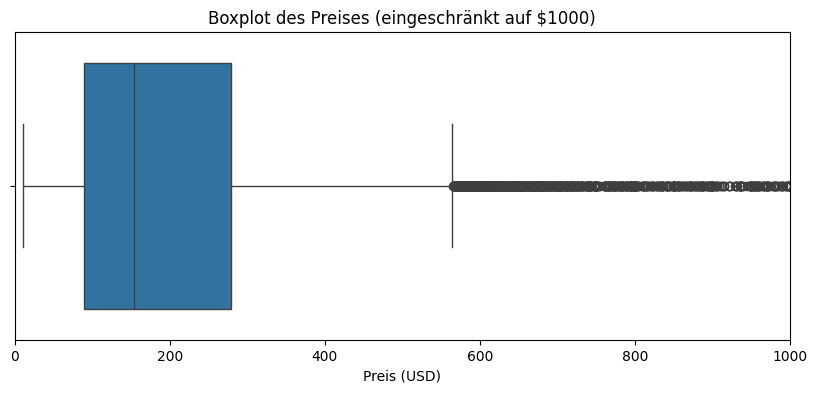

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# 1. Erstellen des Boxplots
sns.boxplot(x='price', data=df_clean)

# 2. EINSCHRÄNKUNG DER X-ACHSE (von 0 bis 1000 USD)
plt.xlim(0, 1000) 

plt.title('Boxplot des Preises (eingeschränkt auf $1000)')
plt.xlabel('Preis (USD)')
plt.show()

#### Scatterplots

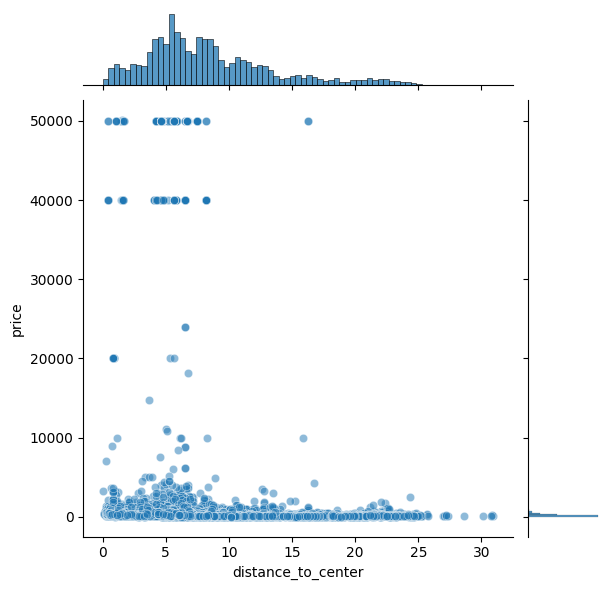

In [154]:
sns.jointplot(x='distance_to_center', y='price', data=df1, alpha=0.5)

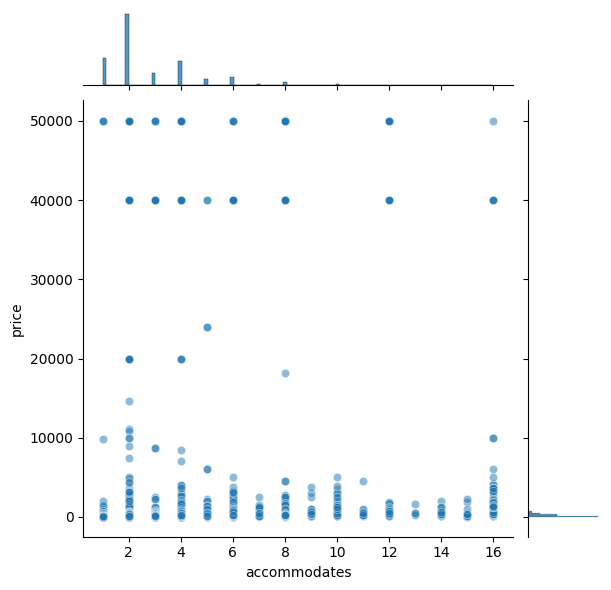

In [155]:
sns.jointplot(x='accommodates', y='price', data=df1, alpha=0.5)

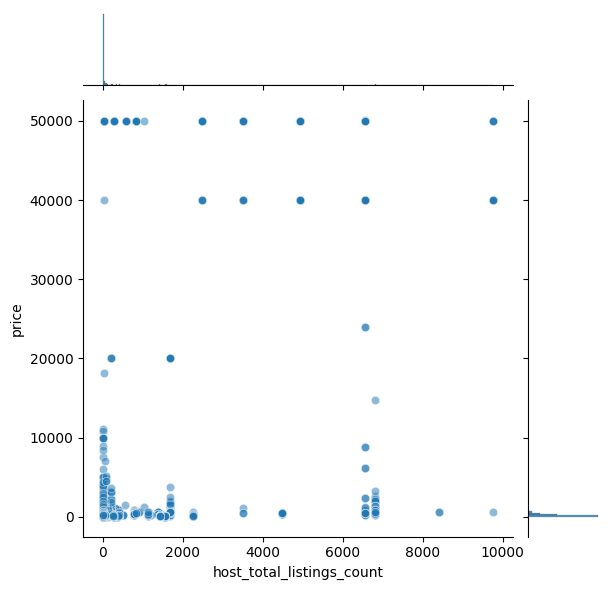

In [156]:
sns.jointplot(x='host_total_listings_count', y='price', data=df1, alpha=0.5)

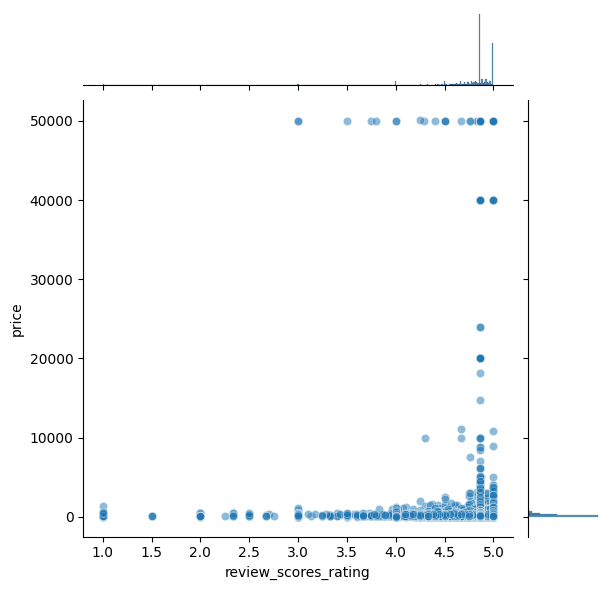

In [157]:

sns.jointplot(x='review_scores_rating', y='price', data=df1, alpha=0.5)

### Zielvariable Price - mit ln-transformation

Erstellen der neuen Spalte 'ln_price':

In [39]:
import numpy as np


df1['ln_price'] = np.log1p(df1['price'])

print("✅ Spalte 'ln_price' erfolgreich erstellt.")
print(df1[['price', 'ln_price']].head())

✅ Spalte 'ln_price' erfolgreich erstellt.
   price  ln_price
0   66.0  4.204693
4   76.0  4.343805
5   97.0  4.584967
7   60.0  4.110874
8  425.0  6.054439


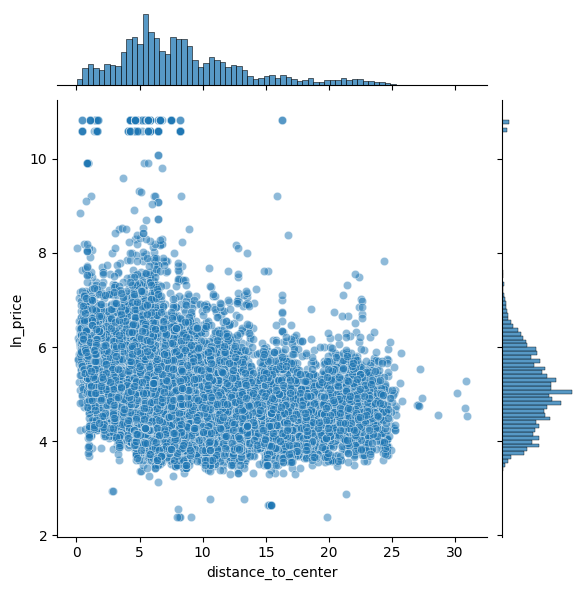

In [34]:
sns.jointplot(x='distance_to_center', y='ln_price', data=df1, alpha=0.5)

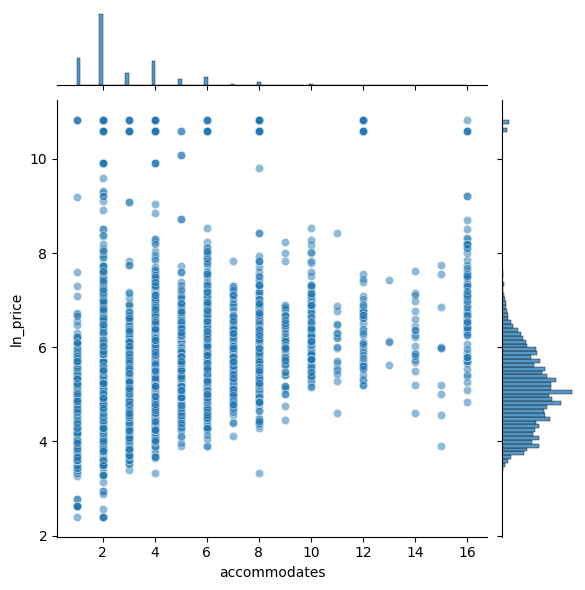

In [35]:
sns.jointplot(x='accommodates', y='ln_price', data=df1, alpha=0.5)

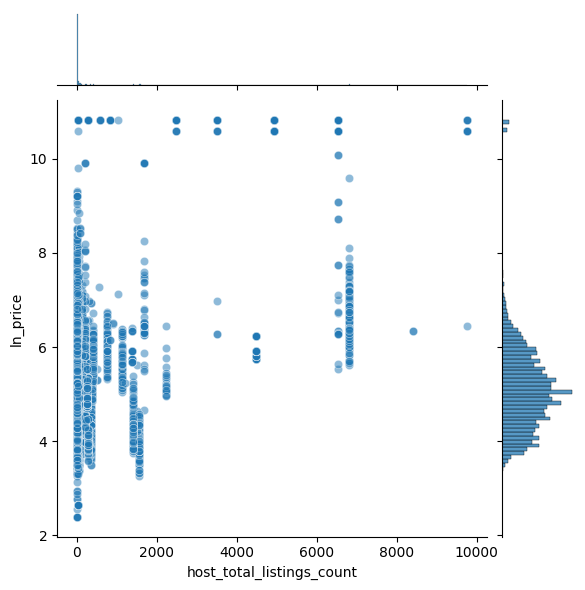

In [36]:
sns.jointplot(x='host_total_listings_count', y='ln_price', data=df1, alpha=0.5)

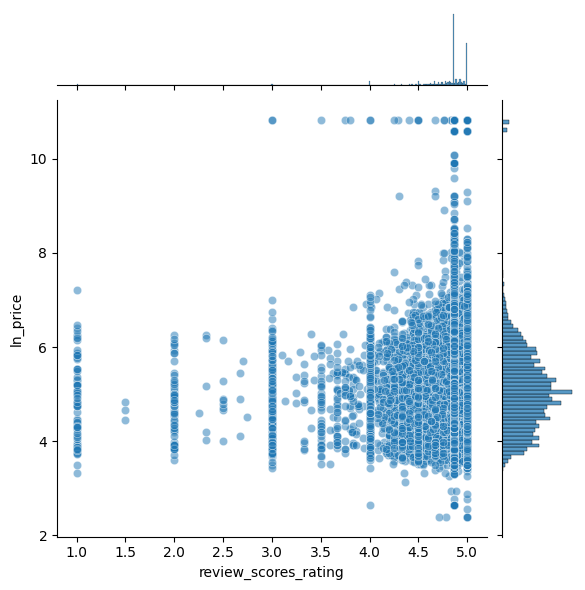

In [37]:
sns.jointplot(x='review_scores_rating', y='ln_price', data=df1, alpha=0.5)

### Gemeinsame Visualisierung von 'price' und 'ln_price'

KeyError: 'ln_price'

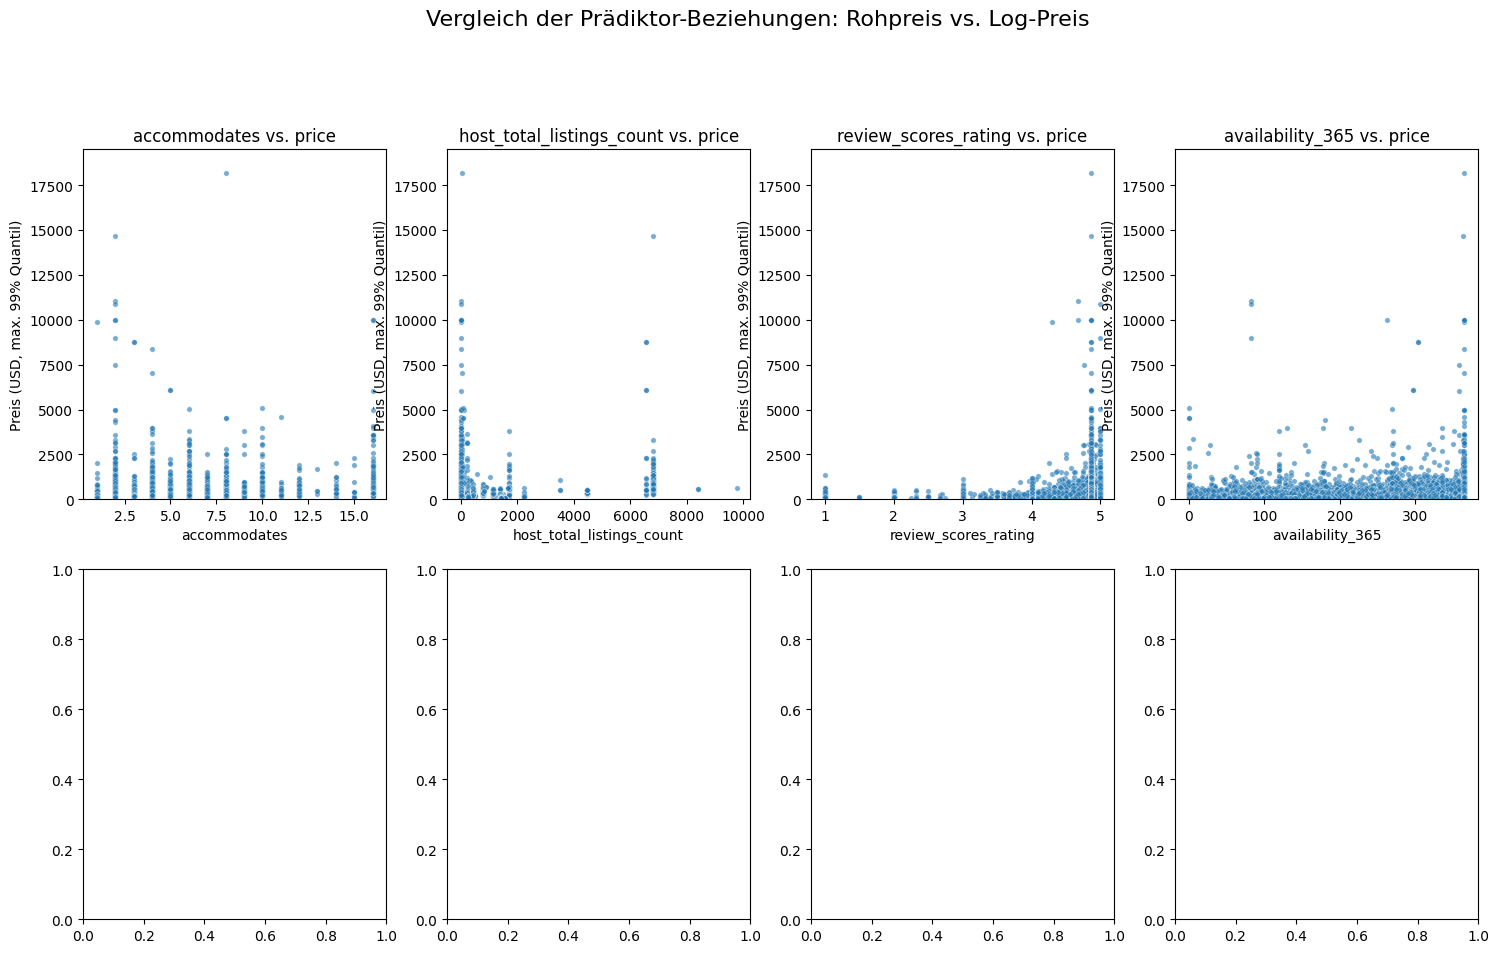

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Nur zur Sicherheit, falls nicht importiert

# Annahme: df_clean enthält die Spalten 'price' und 'ln_price'
PREDICTOR_SPALTEN = ['accommodates', 'host_total_listings_count', 'review_scores_rating', 'availability_365']
TARGET_SPALTEN = ['price', 'ln_price']

# Definition des maximalen Werts für die y-Achse des rohen Preises (zur besseren Sichtbarkeit)
PRICE_LIMIT = df_clean['price'].quantile(0.99)

# Erstellen der großen Figur: 2 Reihen, 3 Spalten (2x3 Grid)
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
plt.suptitle('Vergleich der Prädiktor-Beziehungen: Rohpreis vs. Log-Preis', fontsize=16, y=1.02)

# Abflachen des Achsen-Arrays, um es leicht durchlaufen zu können
# axes[0, 0], axes[0, 1], axes[0, 2] = Erste Reihe (price)
# axes[1, 0], axes[1, 1], axes[1, 2] = Zweite Reihe (ln_price)

# Äußere Schleife: Durchläuft die Zielvariablen (Reihen)
for row_index, target in enumerate(TARGET_SPALTEN):
    
    # Innere Schleife: Durchläuft die Prädiktoren (Spalten)
    for col_index, predictor in enumerate(PREDICTOR_SPALTEN):
        
        # Zugriff auf die korrekte Subplot-Position (axes[Reihe, Spalte])
        ax = axes[row_index, col_index]
        
        # Erstellen des Scatterplots
        sns.scatterplot(
            x=df_clean[predictor], 
            y=df_clean[target], 
            ax=ax, 
            alpha=0.6, 
            s=15 # Größe der Punkte
        )
        
        ax.set_title(f'{predictor} vs. {target}')
        ax.set_xlabel(predictor)
        
        # Nur für die obere Reihe (price): Y-Achse auf PRICE_LIMIT begrenzen
        if target == 'price':
            ax.set_ylim(0, PRICE_LIMIT)
            ax.set_ylabel('Preis (USD, max. 99% Quantil)')
        else:
            ax.set_ylabel('Log(1 + Preis)')
            
# Sicherstellen, dass die Plots sich nicht überlappen
plt.tight_layout()
plt.show()

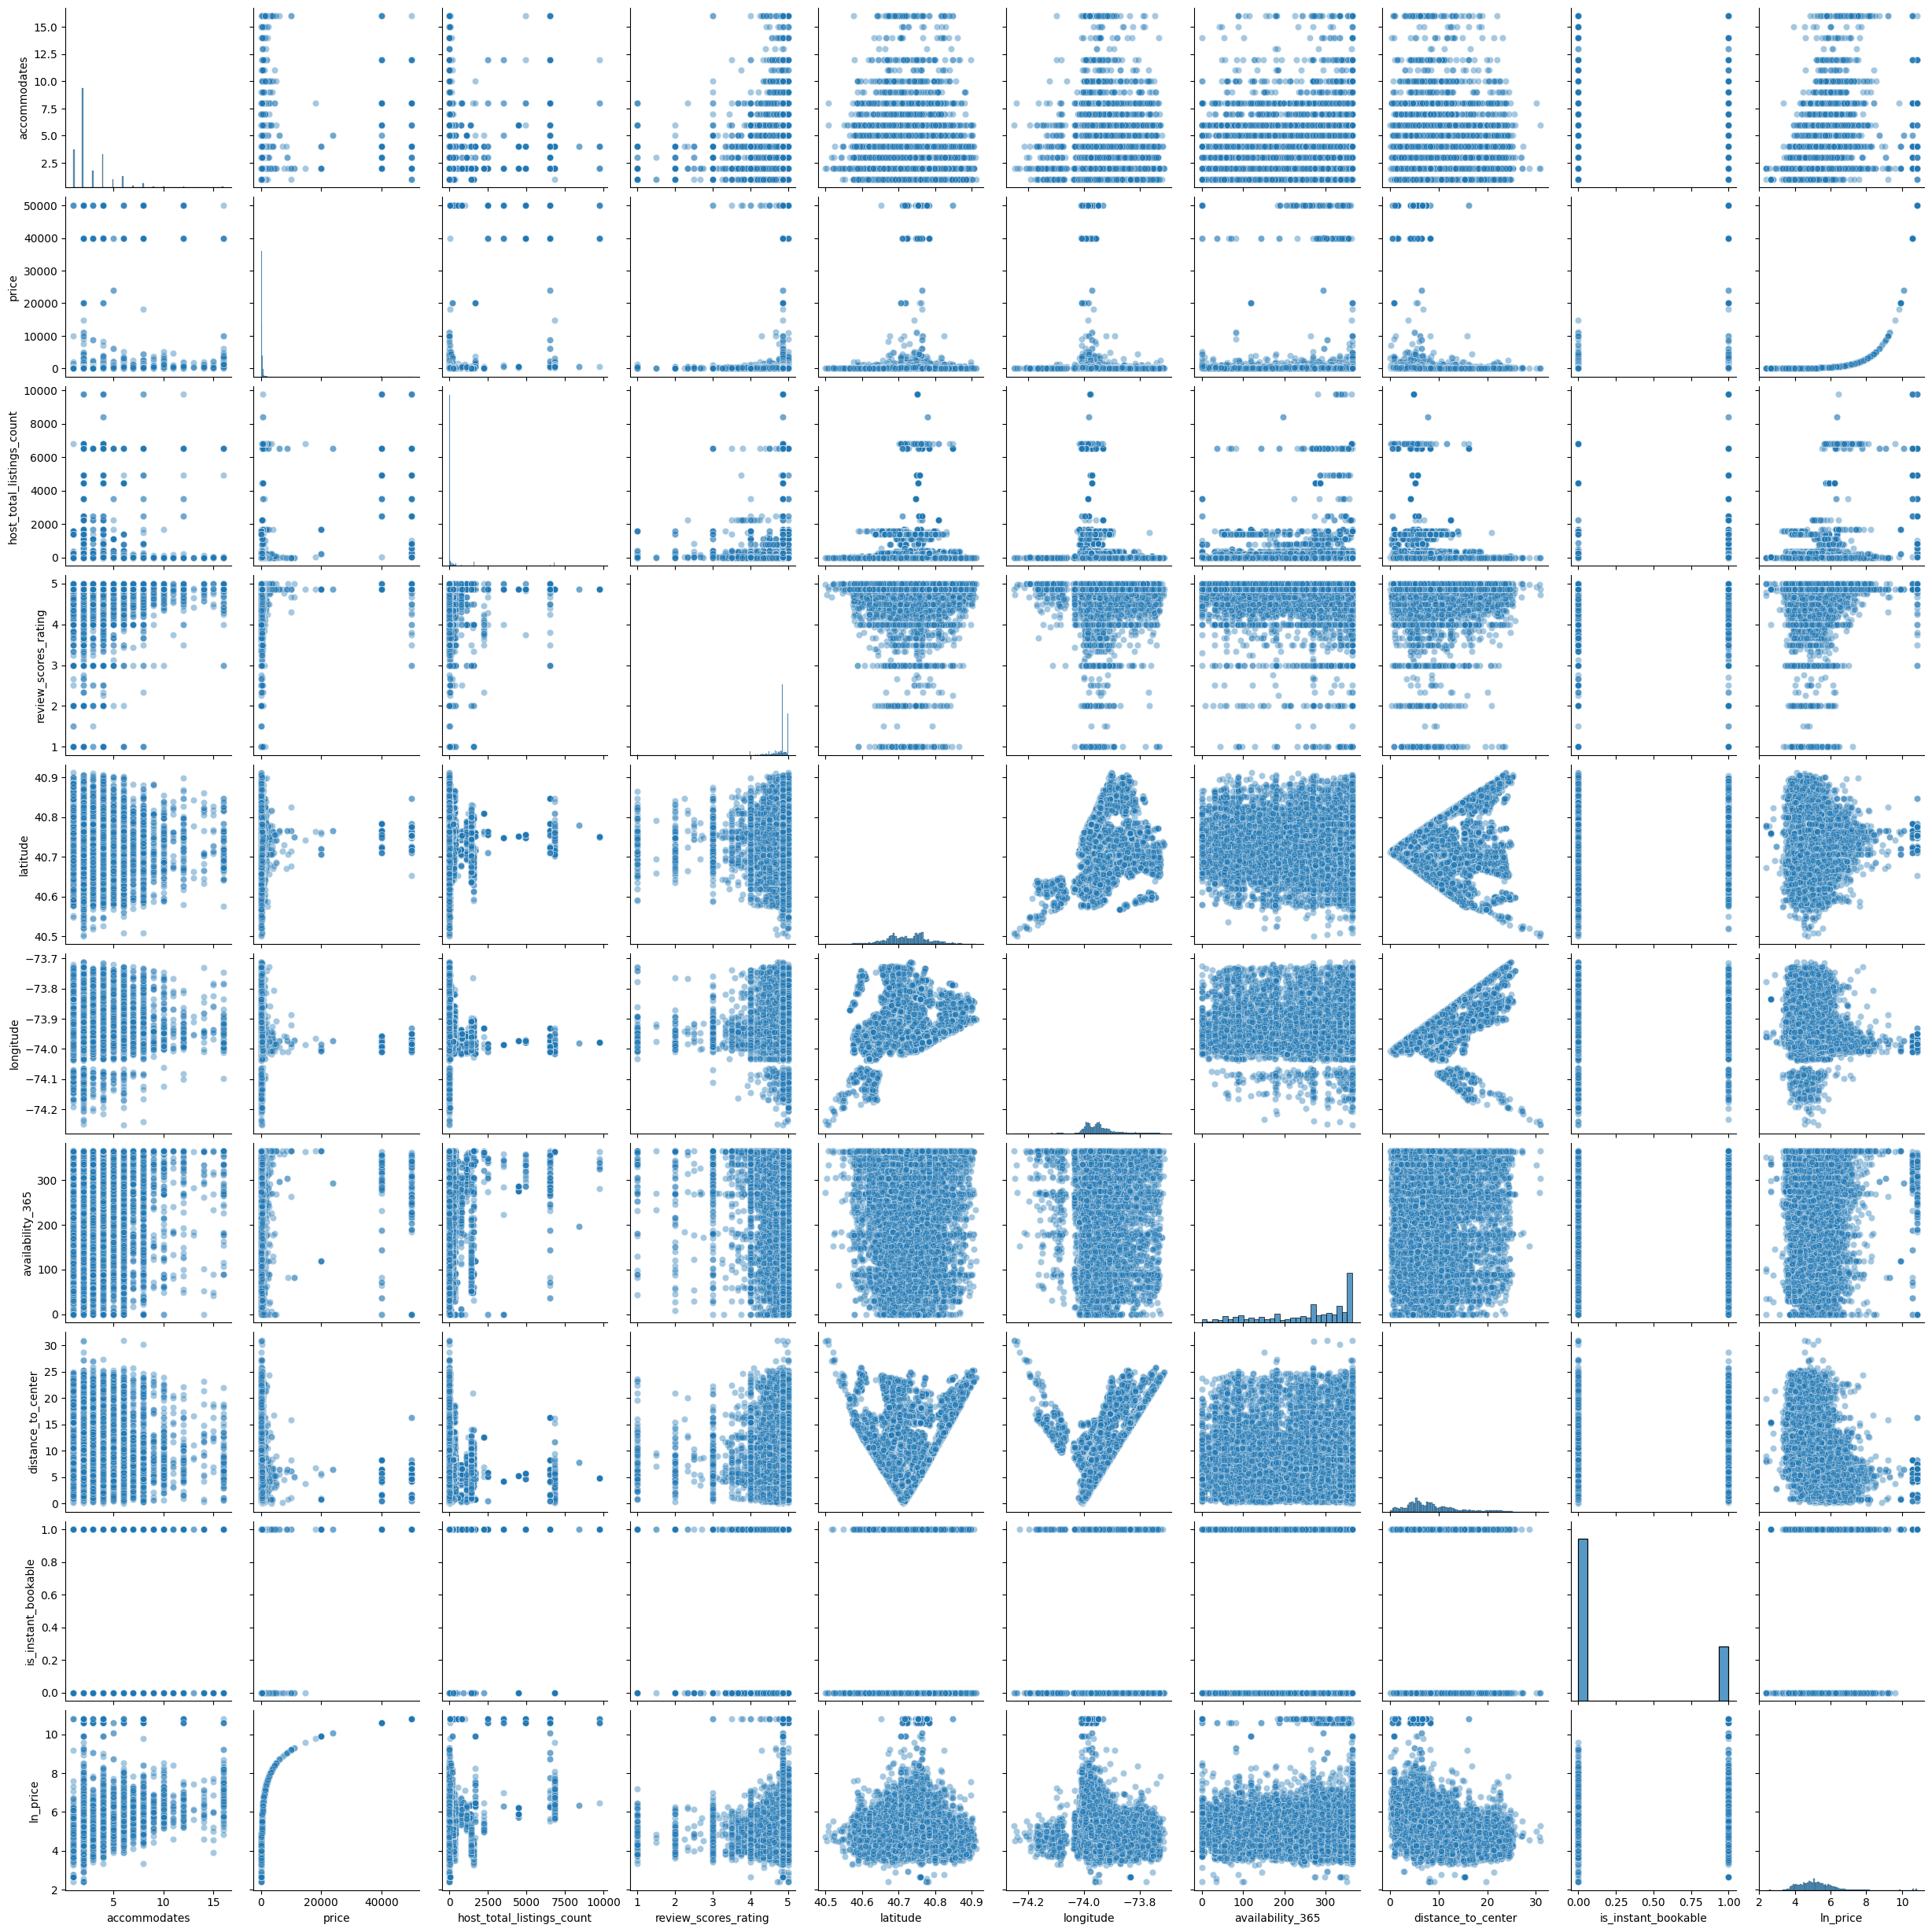

In [41]:
sns.pairplot(df1, kind='scatter', plot_kws={'alpha':0.4})

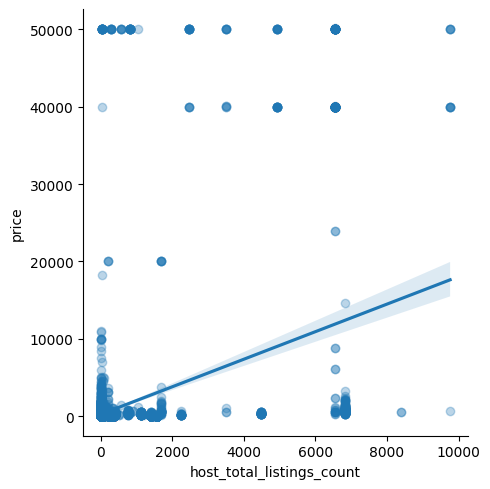

In [42]:
sns.lmplot(x = 'host_total_listings_count', 
           y = 'price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

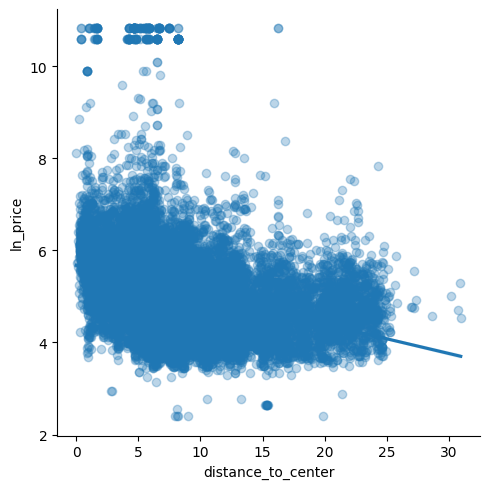

In [43]:
sns.lmplot(x = 'distance_to_center', 
           y = 'ln_price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

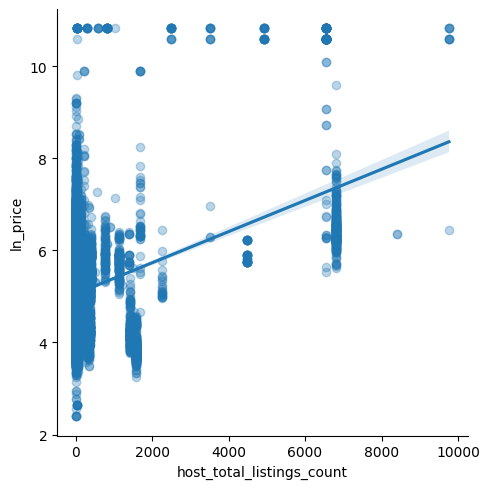

In [44]:
sns.lmplot(x = 'host_total_listings_count', 
           y = 'ln_price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

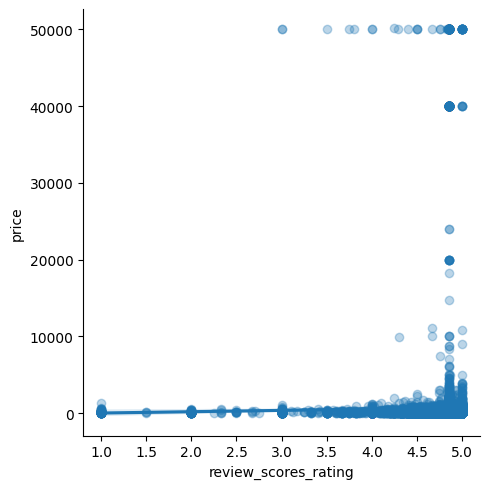

In [45]:
sns.lmplot(x = 'review_scores_rating', 
           y = 'price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

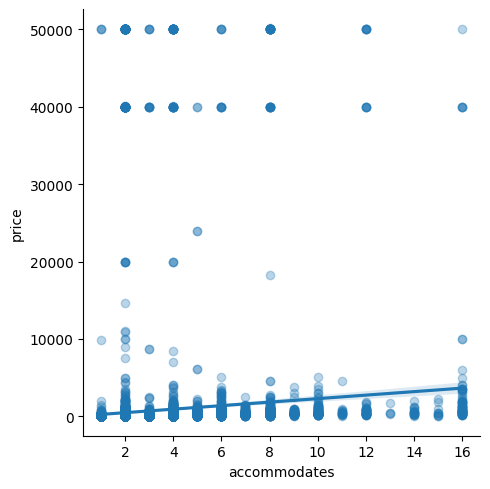

In [46]:
sns.lmplot(x = 'accommodates', 
           y = 'price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

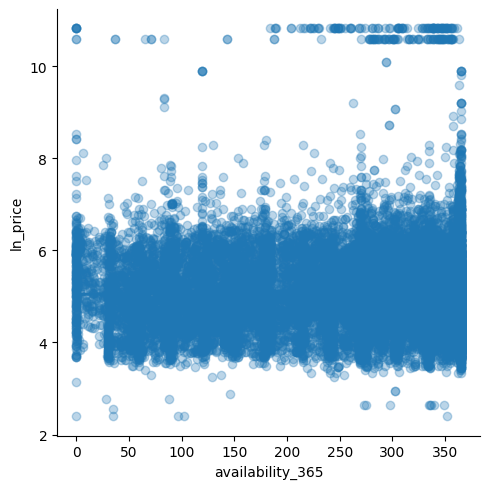

In [47]:
sns.lmplot(x = 'availability_365', 
           y = 'ln_price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
X = df1[['distance_to_center', 'host_total_listings_count', 'accommodates', 'availability_365', 'is_instant_bookable']]
y = df1['ln_price']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [51]:
y_train

12857    4.727388
20012    5.683580
22927    5.062595
1178     5.129899
30404    6.723832
           ...   
24089    5.908083
24937    4.394449
15398    4.304065
1770     5.429346
29669    4.653960
Name: ln_price, Length: 14929, dtype: float64

# Training the model

In [52]:
from sklearn.linear_model import LinearRegression

In [53]:
lm = LinearRegression()

In [54]:
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Koeffizienten

In [55]:
lm.coef_

array([-5.03841298e-02,  3.11916514e-04,  2.12663834e-01, -9.94458972e-05,
        5.00396425e-01])

In [56]:
cdf = pd.DataFrame(lm.coef_, X.columns, columns=['Coef'])
print(cdf)

                               Coef
distance_to_center        -0.050384
host_total_listings_count  0.000312
accommodates               0.212664
availability_365          -0.000099
is_instant_bookable        0.500396


### Predictions

In [57]:
predictions = lm.predict(X_test)

In [58]:
predictions

array([5.16201523, 4.83489863, 5.16119372, ..., 4.92846657, 5.24509393,
       7.38442317], shape=(6399,))

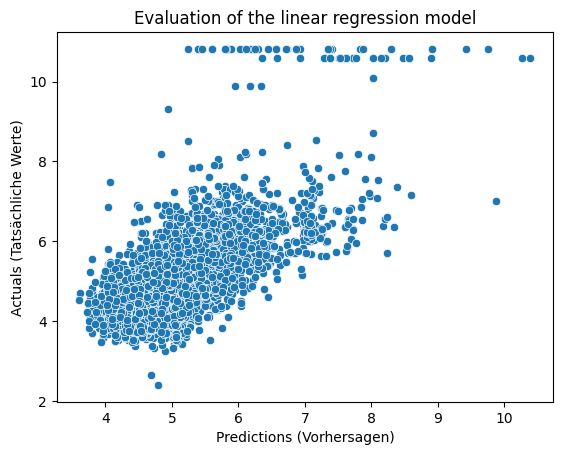

In [60]:
sns.scatterplot(x=predictions, y=y_test)
plt.xlabel("Predictions (Vorhersagen)")
plt.ylabel("Actuals (Tatsächliche Werte)")
plt.title("Evaluation of the linear regression model")
plt.show()

In [61]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [62]:
print("Mean Absolute Error: ", mean_absolute_error(y_test, predictions))
print("Mean Squared Error: ", mean_squared_error(y_test, predictions))
print("RMSE: ", math.sqrt(mean_squared_error(y_test, predictions)))

Mean Absolute Error:  0.5174487406121849
Mean Squared Error:  0.5399855703608061
RMSE:  0.7348371046434754


## Ent-Transformation (wichtiger Schritt)

Um die Modellgüte korrekt zu interpretieren, müssen die Fehlerwerte aus dem logarithmierten Raum zurück in die ursprüngliche Einheit **USD** transformiert werden.

Da im Modell die natürliche Logarithmusfunktion verwendet wurde,

$$
\[
y_{\text{log}} = \ln(y),
\]
$$
erfolgt die Rücktransformation mit der **Exponentialfunktion**:
$$
\[
y = e^{y_{\text{log}}}
\]
$$
---

## Schätzung des mittleren absoluten Fehlers (MAE in USD)

Der mittlere absolute Fehler im Log-Raum (\(\text{MAE}_{\text{log}}\)) lässt sich näherungsweise in den ursprünglichen Raum transformieren durch:

$$
\[
\text{MAE}_{\text{USD}} \approx e^{\text{MAE}_{\text{log}}} - 1
\]
$$

Setzt man den geschätzten Wert ein:

$$
\[
\text{MAE}_{\text{USD}} \approx e^{0.59} - 1
\]
$$

$$
\[
\text{MAE}_{\text{USD}} \approx 1.80 - 1 = 0.80
\]
$$
---

## Interpretation

Das bedeutet, dass das Modell im Durchschnitt einen **relativen Fehler von etwa 80 %** aufweist.

### Beispiel

Angenommen, der wahre Preis beträgt:

\[
y = 100 \ \text{USD}
\]

Dann liegt die Modellvorhersage im Mittel in folgendem Bereich:

\[
100 \cdot (1 - 0.80) \le \hat{y} \le 100 \cdot (1 + 0.80)
\]

\[
20 \ \text{USD} \le \hat{y} \le 180 \ \text{USD}
\]

⚠️ Diese Interpretation ist **vereinfachend**, aber notwendig, um die praktische Modellgüte im ursprünglichen Maßstab zu beurteilen.


<Axes: ylabel='ln_price'>

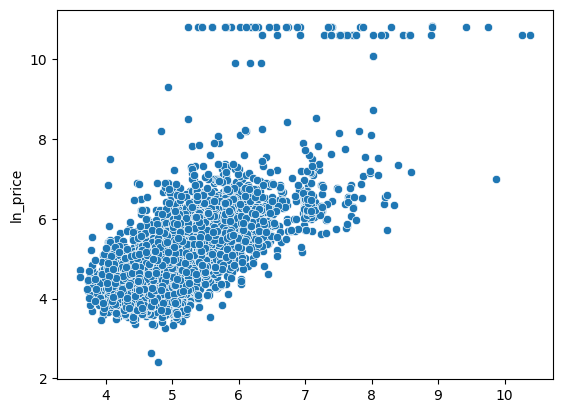

In [63]:
sns.scatterplot(x=predictions, y=y_test)

### Residuals

In [64]:
residuals = y_test - predictions
residuals

23807   -0.185281
20843    0.077756
23495   -0.248539
18970    0.483150
5481    -0.322867
           ...   
26911   -0.635478
13540   -0.611300
20965    0.478705
16030    0.494699
29538    3.212237
Name: ln_price, Length: 6399, dtype: float64

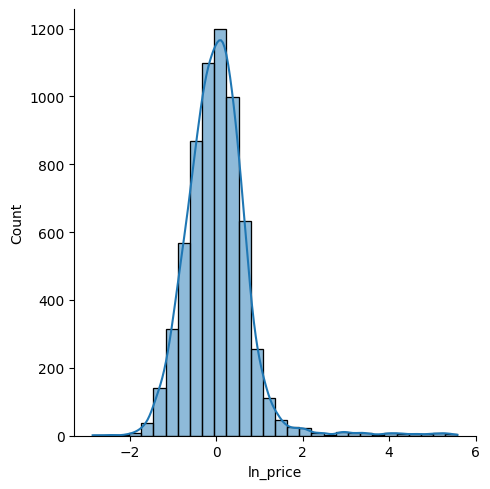

In [65]:
sns.displot(residuals, bins=30, kde=True)

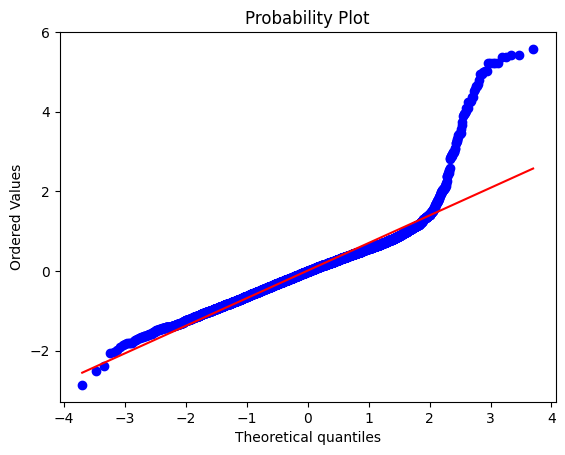

In [66]:
import pylab
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=pylab)
pylab.show()

In [67]:
import numpy as np
from sklearn.metrics import r2_score

# Annahmen: 
# X_test, y_test sind Ihre Testdaten
# model ist Ihr trainiertes Regressionsmodell

# 1. Berechne den R²
y_pred = lm.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R²-Wert: {r2:.4f}")

# 2. Berechne den Adjusted R²
n = X_test.shape[0]  # Stichprobengröße (Anzahl der Testdatenpunkte)
k = X_test.shape[1]  # Anzahl der Features (Spalten)

# Adjusted R² Formel: 1 - (1 - R²) * (n - 1) / (n - k - 1)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
print(f"Adjusted R²-Wert: {adj_r2:.4f}")

R²-Wert: 0.4588
Adjusted R²-Wert: 0.4584
